In [47]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [48]:
GOOGLE_DRIVE_PATH_AFTER_MYDRIVE = "CW_Folder_PG"

## STEP 1 - Dataset Path

In [49]:
import os

DATASET_PATH = f"/content/drive/MyDrive/{GOOGLE_DRIVE_PATH_AFTER_MYDRIVE}/CW_Dataset"

### Imports and Dataset Loader

In [27]:
import cv2
import numpy as np

def load_dataset(image_dir, label_file, img_size=(128, 128)):

    images = []
    labels = []

    with open(label_file, 'r') as f:
        lines = f.readlines()

    for line in lines:
        img_name, label = line.strip().split()

        img_path = os.path.join(image_dir, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, img_size)

        images.append(img)
        labels.append(int(label))

    return np.array(images), np.array(labels)

In [ ]:
#load training set

train_images_path = os.path.join(DATASET_PATH, "train")
train_labels_path = os.path.join(DATASET_PATH, "train", "train_labels.txt")

X, y = load_dataset(train_images_path, train_labels_path)

In [ ]:
#check output

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Labels:", np.unique(y))

## Step 2 - Train / Validation Split (70/30)

In [ ]:
# split data

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.3,      # 70/30 split
    random_state=42,    # reproducibility
    stratify=y          # maintain class balance
)

In [46]:
# check split

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)

print("Training labels distribution:", np.bincount(y_train))
print("Validation labels distribution:", np.bincount(y_val))

Training set: (9310, 128, 128, 3)
Validation set: (3990, 128, 128, 3)
Training labels distribution: [1680 3850 2100 1680]
Validation labels distribution: [ 720 1650  900  720]


**SAVE SPLIT DATA**

In [ ]:
np.save("/content/drive/MyDrive/CW_Folder_PG/X_train.npy", X_train)
np.save("/content/drive/MyDrive/CW_Folder_PG/X_val.npy", X_val)
np.save("/content/drive/MyDrive/CW_Folder_PG/y_train.npy", y_train)
np.save("/content/drive/MyDrive/CW_Folder_PG/y_val.npy", y_val)

**LOAD saved data** (saves time and CPU effort)

In [50]:
import numpy as np

X_train = np.load("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/X_train.npy")
X_val = np.load("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/X_val.npy")
y_train = np.load("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/y_train.npy")
y_val = np.load("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/y_val.npy")

## STEP 3 - Preprocessing

In [ ]:
# normalize images

X_train = X_train / 255.0
X_val = X_val / 255.0

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

In [ ]:
# Convert to grayscale (for HOG)
import cv2

def convert_to_gray(images):
    gray_images = []

    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray_images.append(gray)

    return np.array(gray_images)

X_train_gray = convert_to_gray(X_train)
X_val_gray = convert_to_gray(X_val)

In [ ]:
# check shapes

print("RGB shape:", X_train.shape)
print("Gray shape:", X_train_gray.shape)

RGB shape: (9310, 128, 128, 3)
Gray shape: (9310, 128, 128)


## STEP 4 - HOG Feature Extraction

In [ ]:
from skimage.feature import hog

In [ ]:
# HOG function

def extract_hog_features(images):

    hog_features = []

    for img in images:
        features = hog(
            img,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            orientations=9,
            block_norm='L2-Hys'
        )

        hog_features.append(features)

    return np.array(hog_features)

In [ ]:
# Applying HOG

X_train_hog = extract_hog_features(X_train_gray)
X_val_hog = extract_hog_features(X_val_gray)

# checking output
print("HOG train shape:", X_train_hog.shape)
print("HOG val shape:", X_val_hog.shape)

HOG train shape: (9310, 8100)
HOG val shape: (3990, 8100)


**Save HOG features**

In [ ]:
np.save("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/X_train_hog.npy", X_train_hog)
np.save("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/X_val_hog.npy", X_val_hog)

**LOAD saved HOG features** (later in case)

In [24]:
X_train_hog = np.load("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/X_train_hog.npy")
X_val_hog = np.load("/content/drive/MyDrive/CW_Folder_PG/Processed_Data/X_val_hog.npy")

## STEP 5 - CROSS-VALIDATION

In [4]:
#Import
from sklearn.model_selection import cross_val_score
import numpy as np

### SVM Cross Validation

In [11]:
# SVM Hyperparameter Search using Cross Validation

from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

print("SVM Hyperparameter Tuning with Cross Validation...\n")

svm_results = []

# Try different combinations
for kernel in ['linear', 'rbf']:
    for C in [1, 10]:

        svm = SVC(kernel=kernel, C=C)

        scores = cross_val_score(
            svm,
            X_train_hog,
            y_train,
            cv=3,
            scoring='accuracy'
        )

        mean_score = scores.mean()
        std_score = scores.std()

        print(f"Kernel={kernel}, C={C} → Mean={mean_score:.4f}, Std={std_score:.4f}")

        svm_results.append((kernel, C, mean_score, std_score))

SVM Hyperparameter Tuning with Cross Validation...

Kernel=linear, C=1 → Mean=0.6958, Std=0.0062
Kernel=linear, C=10 → Mean=0.6958, Std=0.0062
Kernel=rbf, C=1 → Mean=0.7491, Std=0.0063
Kernel=rbf, C=10 → Mean=0.7567, Std=0.0063


In [12]:
# Find best SVM configuration
best_svm = max(svm_results, key=lambda x: x[2])  # based on mean accuracy

print("\nBest SVM Configuration:")
print(f"Kernel={best_svm[0]}, C={best_svm[1]}")
print(f"Accuracy: {best_svm[2]:.4f} ± {best_svm[3]:.4f}")


Best SVM Configuration:
Kernel=rbf, C=10
Accuracy: 0.7567 ± 0.0063


### MLP Cross Validation

In [13]:
# MLP Hyperparameter Search using Cross Validation

from sklearn.neural_network import MLPClassifier

print("\nMLP Hyperparameter Tuning with Cross Validation...\n")

mlp_results = []

# Try different configurations
for size in [(64,), (128,), (128,64)]:
    for solver in ['adam', 'sgd']:

        mlp = MLPClassifier(
            hidden_layer_sizes=size,
            solver=solver,
            max_iter=20,        # keep small for CV speed
            random_state=42
        )

        scores = cross_val_score(
            mlp,
            X_train_hog,
            y_train,
            cv=3,
            scoring='accuracy'
        )

        mean_score = scores.mean()
        std_score = scores.std()

        print(f"Size={size}, Solver={solver} - Mean={mean_score:.4f}, Std={std_score:.4f}")

        mlp_results.append((size, solver, mean_score, std_score))


MLP Hyperparameter Tuning with Cross Validation...



/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Size=(64,), Solver=adam - Mean=0.7316, Std=0.0074


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Size=(64,), Solver=sgd - Mean=0.7060, Std=0.0045


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Size=(128, 64), Solver=adam - Mean=0.7020, Std=0.0202


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


Size=(128, 64), Solver=sgd - Mean=0.7199, Std=0.0036


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
best_mlp = max(mlp_results, key=lambda x: x[2])

print("\nBest MLP Configuration:")
print(f"Size={best_mlp[0]}, Solver={best_mlp[1]}, Accuracy={best_mlp[2]:.4f}")


Best MLP Configuration:
Size=(128,), Solver=adam, Accuracy=0.7380


## STEP 6 - FULL TRAINING

## **Model** **1**: HOG + SVM

In [1]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [2]:
#create SVM
svm_model = SVC(kernel='rbf', C=10)

In [10]:
# train SVM
svm_model.fit(X_train_hog, y_train)

SVC(C=10)

**Save SVM model**

In [11]:
import joblib

joblib.dump(svm_model, "/content/drive/MyDrive/CW_Folder_PG/Models/svm_model.pkl")

['/content/drive/MyDrive/Computer Vision_CW_PG/Models/svm_model.pkl']

In [12]:
# predict
y_pred_svm = svm_model.predict(X_val_hog)

#evaluate
accuracy_svm = accuracy_score(y_val, y_pred_svm)
print("SVM Accuracy:", accuracy_svm)

SVM Accuracy: 0.7694235588972431


In [13]:
#(for report)
from sklearn.metrics import classification_report
print(classification_report(y_val, y_pred_svm))

              precision    recall  f1-score   support

           0       0.95      0.88      0.92       720
           1       0.79      0.89      0.83      1650
           2       0.60      0.52      0.56       900
           3       0.74      0.69      0.72       720

    accuracy                           0.77      3990
   macro avg       0.77      0.75      0.76      3990
weighted avg       0.77      0.77      0.77      3990



## **Model** **2** : HOG + MLP

In [14]:
from sklearn.neural_network import MLPClassifier

In [15]:
# create final MLP model
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128,),
    solver='adam',
    max_iter=50,
    random_state=42
)

In [16]:
# train MLP
mlp_model.fit(X_train_hog, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(hidden_layer_sizes=(128,), max_iter=50, random_state=42)

In [17]:
# predict
y_pred_mlp = mlp_model.predict(X_val_hog)

In [18]:
#evaluate
from sklearn.metrics import accuracy_score

accuracy_mlp = accuracy_score(y_val, y_pred_mlp)
print("MLP Accuracy:", accuracy_mlp)

MLP Accuracy: 0.731328320802005


**Save MLP model**

In [19]:
joblib.dump(mlp_model, "/content/drive/MyDrive/CW_Folder_PG/Models/mlp_model.pkl")

['/content/drive/MyDrive/Computer Vision_CW_PG/Models/mlp_model.pkl']

In [13]:
# for memory cleanup to free RAM usage
#del X_train
#del X_val
#del X_train_gray
#del X_val_gray

## **Model** **3** : CNN (Deep Learning Model, **GPU stage**)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# build CNN
cnn_model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dense(4, activation='softmax')  # 4 classes
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile model
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [ ]:
# train model with validation monitoring
# Early stopping is applied based on validation loss to prevent overfitting and retain the best model weights.
# Basic hyperparameters such as number of epochs and batch size were selected empirically, representing light hyperparameter tuning.
history = cnn_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop]
)

In [ ]:
# evaluate

loss, accuracy = cnn_model.evaluate(X_val, y_val)
print("CNN Accuracy:", accuracy)

125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7637 - loss: 0.6235
CNN Accuracy: 0.7636591196060181


**SAVE CNN MODEL**

In [ ]:
cnn_model.save("/content/drive/MyDrive/CW_Folder_PG/Models/cnn_model.h5")

In [ ]:
# evaluate on test set

loss, test_accuracy = cnn_model.evaluate(X_test, y_test)

27/27 ━━━━━━━━━━━━━━━━━━━━ 11s 352ms/step - accuracy: 0.7800 - loss: 0.5901


## STEP 7 - Test Dataset Evaluation

In [51]:
# load test dataset
test_images_path = os.path.join(DATASET_PATH, "test")
test_labels_path = os.path.join(DATASET_PATH, "test", "test_labels.txt")

X_test, y_test = load_dataset(test_images_path, test_labels_path)

In [52]:
# preprocess
X_test = X_test / 255.0
X_test = X_test.astype("float32")

## **Detailed report**

### 1. SVM on Test

In [53]:
import cv2
import numpy as np
from skimage.feature import hog
import joblib

def convert_to_gray(images):
    gray_images = []

    for img in images:
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        gray_images.append(gray)

    return np.array(gray_images)

def extract_hog_features(images):

    hog_features = []

    for img in images:
        features = hog(
            img,
            pixels_per_cell=(8, 8),
            cells_per_block=(2, 2),
            orientations=9,
            block_norm='L2-Hys'
        )

        hog_features.append(features)

    return np.array(hog_features)

X_test_gray = convert_to_gray(X_test)
X_test_hog = extract_hog_features(X_test_gray)

# Load the SVM model
svm_model = joblib.load("/content/drive/MyDrive/CW_Folder_PG/Models/svm_model.pkl")

y_pred_svm = svm_model.predict(X_test_hog)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
print("SVM Test Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Test Precision:", precision_score(y_test, y_pred_svm, average='weighted'))
print("SVM Test Recall:", recall_score(y_test, y_pred_svm, average='weighted'))
print("SVM Test F1-score:", f1_score(y_test, y_pred_svm, average='weighted'))

SVM Test Accuracy: 0.7752941176470588
SVM Test Precision: 0.7715854944925843
SVM Test Recall: 0.7752941176470588
SVM Test F1-score: 0.7722887539428994


#### Classification Report - SVM

In [42]:
from sklearn.metrics import classification_report

print("\nClassification Report of SVM:")
print(classification_report(y_test, y_pred_svm))


Classification Report of SVM:
              precision    recall  f1-score   support

           0       0.93      0.90      0.92       150
           1       0.80      0.87      0.84       350
           2       0.63      0.57      0.60       200
           3       0.73      0.69      0.71       150

    accuracy                           0.78       850
   macro avg       0.77      0.76      0.77       850
weighted avg       0.77      0.78      0.77       850



#### Confusion Matrix - SVM


Confusion Matrix:
 [[135  15   0   0]
 [ 10 306  31   3]
 [  0  51 114  35]
 [  0  10  36 104]]


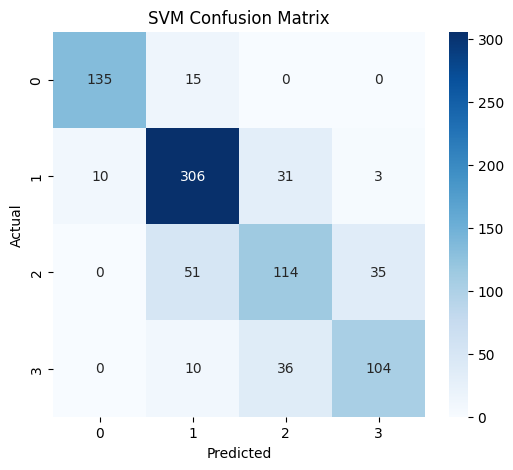

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")
plt.show()

### 2. MLP on test

In [33]:
import joblib
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Load the MLP model
mlp_model = joblib.load("/content/drive/MyDrive/CW_Folder_PG/Models/mlp_model.pkl")

y_pred_mlp = mlp_model.predict(X_test_hog)
print("MLP Test Accuracy:", accuracy_score(y_test, y_pred_mlp))
print("MLP Test Precision:", precision_score(y_test, y_pred_mlp, average='weighted'))
print("MLP Test Recall:", recall_score(y_test, y_pred_mlp, average='weighted'))
print("MLP Test F1-score:", f1_score(y_test, y_pred_mlp, average='weighted'))

MLP Test Accuracy: 0.7388235294117647
MLP Test Precision: 0.7361564902954992
MLP Test Recall: 0.7388235294117647
MLP Test F1-score: 0.7362271915517877


#### Classification Report - MLP

In [43]:
print("\nClassification Report of MLP:")
print(classification_report(y_test, y_pred_mlp))


Classification Report of MLP:
              precision    recall  f1-score   support

           0       0.94      0.88      0.91       150
           1       0.79      0.86      0.82       350
           2       0.56      0.55      0.55       200
           3       0.65      0.57      0.61       150

    accuracy                           0.74       850
   macro avg       0.73      0.71      0.72       850
weighted avg       0.74      0.74      0.74       850



#### Confusion Matrix - MLP


Confusion Matrix:
 [[132  17   0   1]
 [  8 301  35   6]
 [  0  52 109  39]
 [  1  12  51  86]]


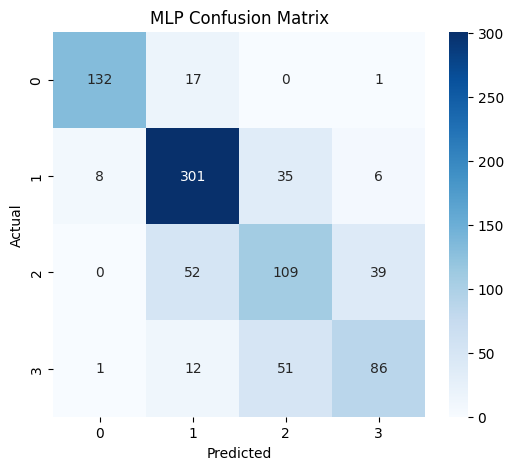

In [35]:
cm = confusion_matrix(y_test, y_pred_mlp)
print("\nConfusion Matrix:\n", cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MLP Confusion Matrix")
plt.show()

### 3. CNN on test

In [36]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import load_model

#load CNN model
cnn_model = load_model("/content/drive/MyDrive/CW_Folder_PG/Models/cnn_model.h5")

y_pred = cnn_model.predict(X_test, verbose=0)
y_pred_cnn = np.argmax(y_pred, axis=1)
print("CNN Test Accuracy:", accuracy_score(y_test, y_pred_cnn))
print("CNN Test Precision:", precision_score(y_test, y_pred_cnn, average='weighted'))
print("CNN Test Recall:", recall_score(y_test, y_pred_cnn, average='weighted'))
print("CNN Test F1-score:", f1_score(y_test, y_pred_cnn, average='weighted'))

CNN Test Accuracy: 0.78
CNN Test Precision: 0.780948694837412
CNN Test Recall: 0.78
CNN Test F1-score: 0.7757595394020026


#### Classification Report - CNN

In [44]:
print("\nClassification Report of CNN:")
print(classification_report(y_test, y_pred_cnn))


Classification Report of CNN:
              precision    recall  f1-score   support

           0       0.86      0.93      0.89       150
           1       0.87      0.85      0.86       350
           2       0.68      0.52      0.59       200
           3       0.64      0.82      0.72       150

    accuracy                           0.78       850
   macro avg       0.76      0.78      0.76       850
weighted avg       0.78      0.78      0.78       850



#### Confusion Matrix - CNN


Confusion Matrix:
 [[139   9   1   1]
 [ 18 297  27   8]
 [  4  32 104  60]
 [  1   5  21 123]]


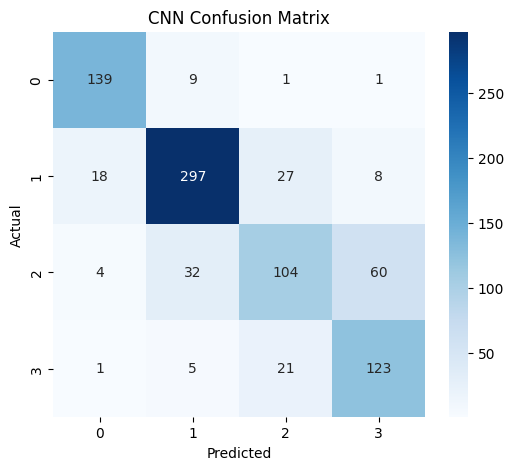

In [38]:
cm = confusion_matrix(y_test, y_pred_cnn)
print("\nConfusion Matrix:\n", cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.show()

## Qualitative comparison

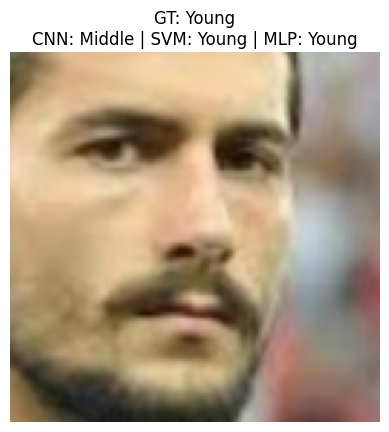

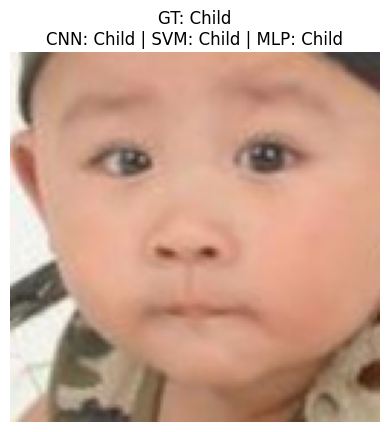

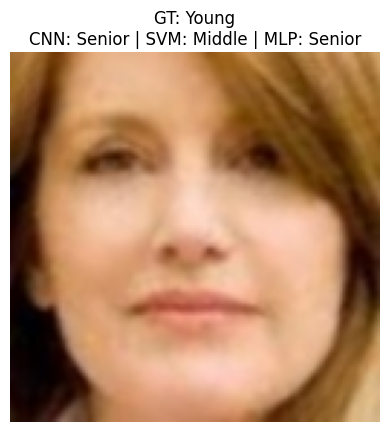

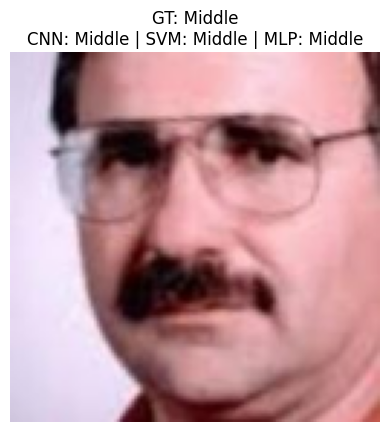

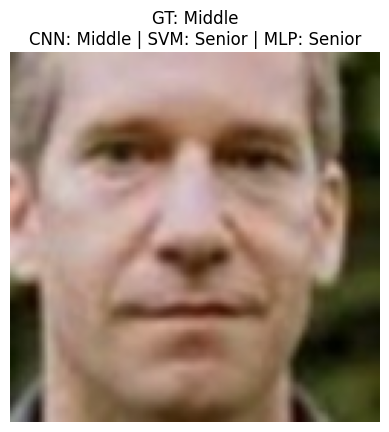

In [41]:
# random test images + predictions

import random
import matplotlib.pyplot as plt
import numpy as np

labels = ["Child", "Young", "Middle", "Senior"]

indices = random.sample(range(len(X_test)), 5)

for i in indices:
    img = X_test[i]

    # Predictions
    pred_cnn = np.argmax(cnn_model.predict(np.expand_dims(img, axis=0), verbose=0))
    pred_svm = svm_model.predict([X_test_hog[i]])[0]
    pred_mlp = mlp_model.predict([X_test_hog[i]])[0]

    plt.imshow(img[..., ::-1])  # BGR → RGB fix
    plt.title(
        f"GT: {labels[y_test[i]]}\n"
        f"CNN: {labels[pred_cnn]} | "
        f"SVM: {labels[pred_svm]} | "
        f"MLP: {labels[pred_mlp]}"
    )
    plt.axis('off')
    plt.show()

##**AI assistance declaration:**
 I declare that the project objective, model design, and data analysis presented in this coursework are my own work. I utilized AI tools to assist with structuring Python code, debugging implementation issues, and refining the wording of report sections. All final implementation, hyperparameter selection, model training, and evaluation of results were performed independently.

**Sample Prompts used:**

Prompt 1 : "How to implement cross-validation for SVM using HOG features in Python?"
Prompt 2: "How to implement an AgeDetection function that processes a video and displays predictions frame by frame in Python?"